In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(2222)

In [2]:
data_finland = pd.read_csv("./ClusteringData/FinlandWhole.txt", header=None).to_numpy()
data_joensuu = pd.read_csv("./ClusteringData/JoensuuRegion.txt", header=None).to_numpy()
print(data_finland.shape, data_joensuu.shape)

(13467, 2) (6014, 2)


In [3]:
def kmeans(data, k, n):
	centroids = data[np.random.choice(data.shape[0], k, replace=False)]
	for _ in range(n):
		labels = np.argmin(np.linalg.norm(data[:, np.newaxis] - centroids, axis=2), axis=1)
		centroids = np.array([data[labels == i].mean(axis=0) for i in range(k)])

	return centroids, labels

In [4]:
centroids_finland, labels_finland = kmeans(data_finland, 7, 10)
centroids_joensuu, labels_joensuu = kmeans(data_joensuu, 5, 10)

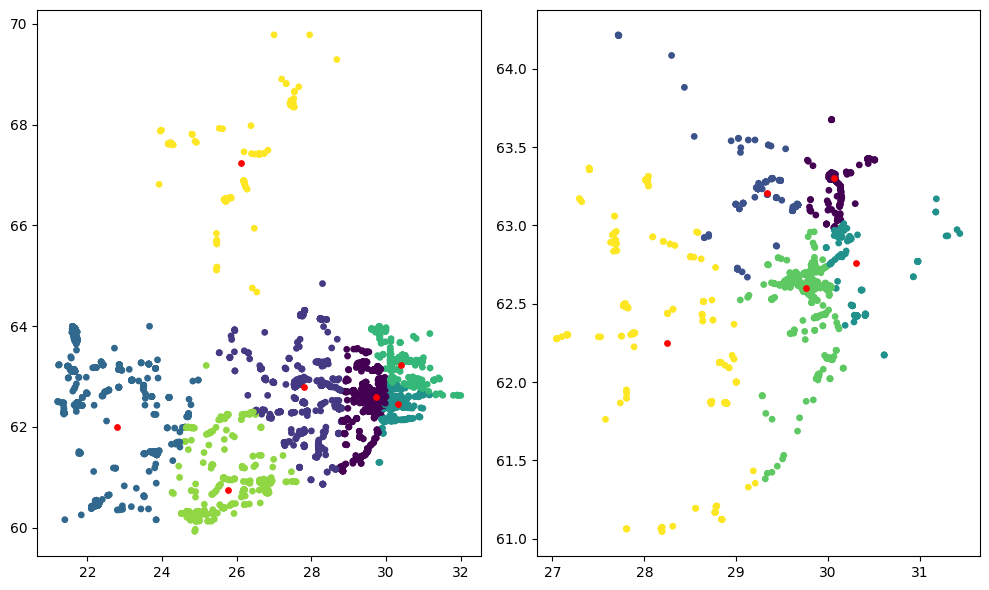

In [5]:
plt.figure(figsize=(10,6))

plt.subplot(1, 2, 1)
plt.scatter(data_finland[:, 0], data_finland[:, 1], s=15, c=labels_finland)
plt.scatter(centroids_finland[:, 0], centroids_finland[:, 1], s=15, color='red')

plt.subplot(1, 2, 2)
plt.scatter(data_joensuu[:, 0], data_joensuu[:, 1], s=15, c=labels_joensuu)
plt.scatter(centroids_joensuu[:, 0], centroids_joensuu[:, 1], s=15, color='red')

plt.tight_layout()

In [6]:
def calculate_entropy(labels, k):
    entropy = 0
    for i in range(k):
        cluster_size = np.sum(labels == i)
        if cluster_size > 0:
            p = cluster_size / len(labels)
            entropy -= p * np.log2(p)
    return entropy

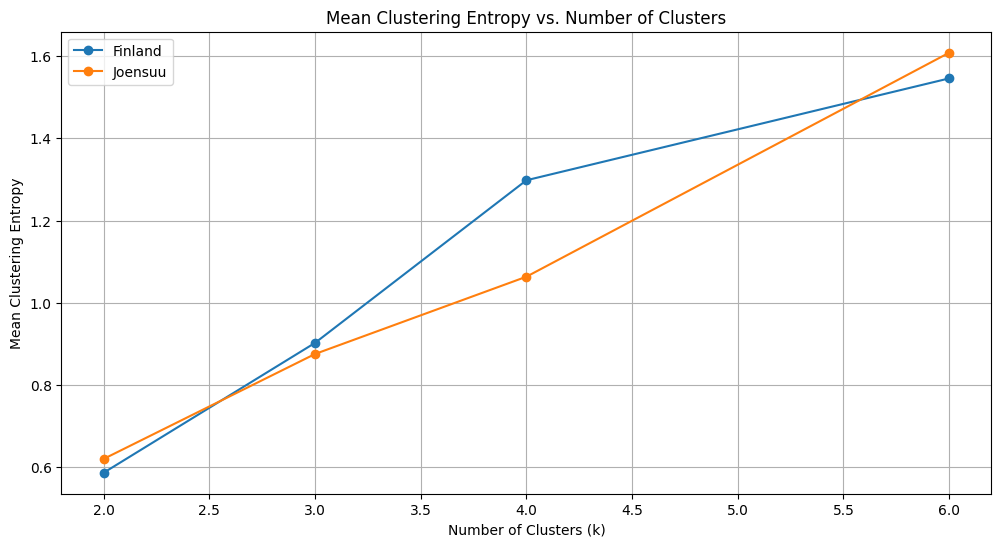

In [7]:
k_values = [2, 3, 4, 6]
max_iters = 10
mean_entropies_finland = []
mean_entropies_joensuu = []

for k in k_values:
    _, labels_finland = kmeans(data_finland, k, max_iters)
    _, labels_joensuu = kmeans(data_joensuu, k, max_iters)
    
    entropy_finland = calculate_entropy(labels_finland, k)
    entropy_joensuu = calculate_entropy(labels_joensuu, k)
    
    mean_entropies_finland.append(entropy_finland)
    mean_entropies_joensuu.append(entropy_joensuu)

plt.figure(figsize=(12, 6))
plt.plot(k_values, mean_entropies_finland, label='Finland', marker='o')
plt.plot(k_values, mean_entropies_joensuu, label='Joensuu', marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Mean Clustering Entropy')
plt.title('Mean Clustering Entropy vs. Number of Clusters')
plt.legend()
plt.grid()
plt.show()


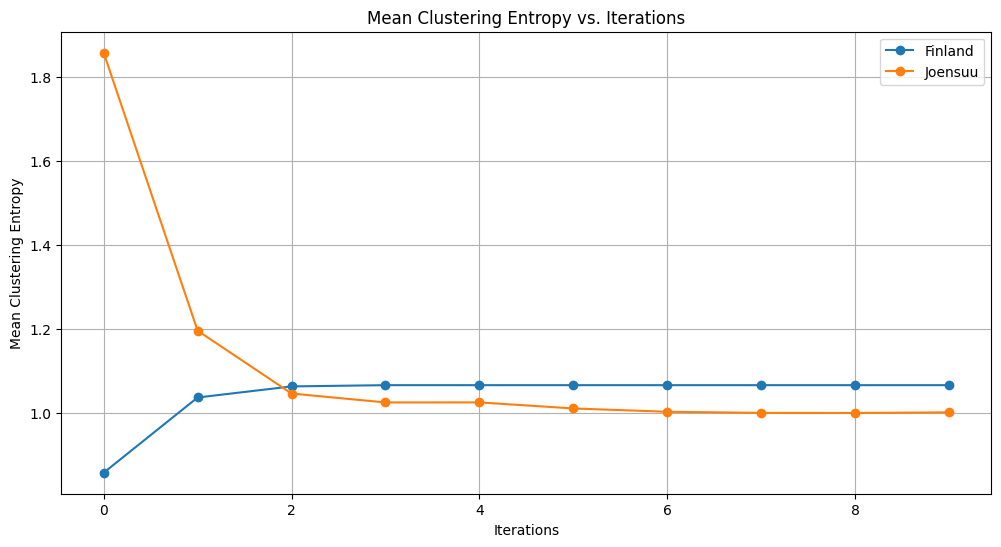

In [8]:
k = 4 
max_iters = 10 

entropies_finland = []
entropies_joensuu = []

centroids_finland = data_finland[np.random.choice(data_finland.shape[0], k, replace=False)]
for _ in range(max_iters):
    labels_finland = np.argmin(np.linalg.norm(data_finland[:, np.newaxis] - centroids_finland, axis=2), axis=1)
    centroids_finland = np.array([data_finland[labels_finland == i].mean(axis=0) for i in range(k)])
    entropy = calculate_entropy(labels_finland, k)
    entropies_finland.append(entropy)

centroids_joensuu = data_joensuu[np.random.choice(data_joensuu.shape[0], k, replace=False)]
for _ in range(max_iters):
    labels_joensuu = np.argmin(np.linalg.norm(data_joensuu[:, np.newaxis] - centroids_joensuu, axis=2), axis=1)
    centroids_joensuu = np.array([data_joensuu[labels_joensuu == i].mean(axis=0) for i in range(k)])
    entropy = calculate_entropy(labels_joensuu, k)
    entropies_joensuu.append(entropy)

plt.figure(figsize=(12, 6))
plt.plot(range(max_iters), entropies_finland, label='Finland', marker='o')
plt.plot(range(max_iters), entropies_joensuu, label='Joensuu', marker='o')
plt.xlabel('Iterations')
plt.ylabel('Mean Clustering Entropy')
plt.title('Mean Clustering Entropy vs. Iterations')
plt.legend()
plt.grid()
plt.show()
